## Notebook Workflow

1. Configure imports and paths for stage-04 odds-ratio analysis.
2. Run duplication and loss odds-ratio permulation tests.
3. Inspect confidence intervals, hit sets, and result summaries.
4. Export outputs for downstream enrichment and figure generation.

In [3]:
import os
import sys

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

# Import modules
import odds_ratio_test as ort
from id_converter import convert_hogs_to_locs

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup


/Users/calvin/anaconda3/envs/orb-selection/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Test for differences in odds of gene loss or duplication between orb-weavers and non-orb-weavers

98 species total, 44 foreground, 54 background
Log odds ratios of LOSS: 
 Mean: -0.50, Stddev: 1.59, Count of HOGs: 8291
Log odds ratios of DUPLICATION: 
 Mean: 0.08, Stddev: 1.14, Count of HOGs: 12096

LAUNCHING PERMULATION TEST

** Maximum occupancy set to 88 for loss test **
** Minimum occupancy set to 30 **

Using 10000 permulation-derived foreground/background assignments.


100%|██████████| 10000/10000 [06:15<00:00, 26.64it/s]


Permulation counter for MEANS:
 Loss: 1974, Duplication: 2229
*********************** RESULTS ***********************

Permulation test with 10000 repetitions
Minimum occupancy: 30; max occupancy (loss): 88
Analysis run on 2026-04-16 at 14:27:52
Foreground list: /Users/calvin/orb-selection/data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/data/N5.tsv
Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 8291 (loss), 12096 (duplication)
Total species: 98
Foreground count: 44
Background count: 54
True mean, loss: -0.500
True standard deviation, loss: 1.591
True mean, duplication: 0.079
True standard deviation, duplication: 1.136

** Permulation P-VALUES ** 

Probability that the null is true for MEAN, loss (alt=less): 0.197
Probability that the null is true for MEAN, duplication (alt=greater): 0.223

Permulated average mean, loss: -0.001
Permulated average s

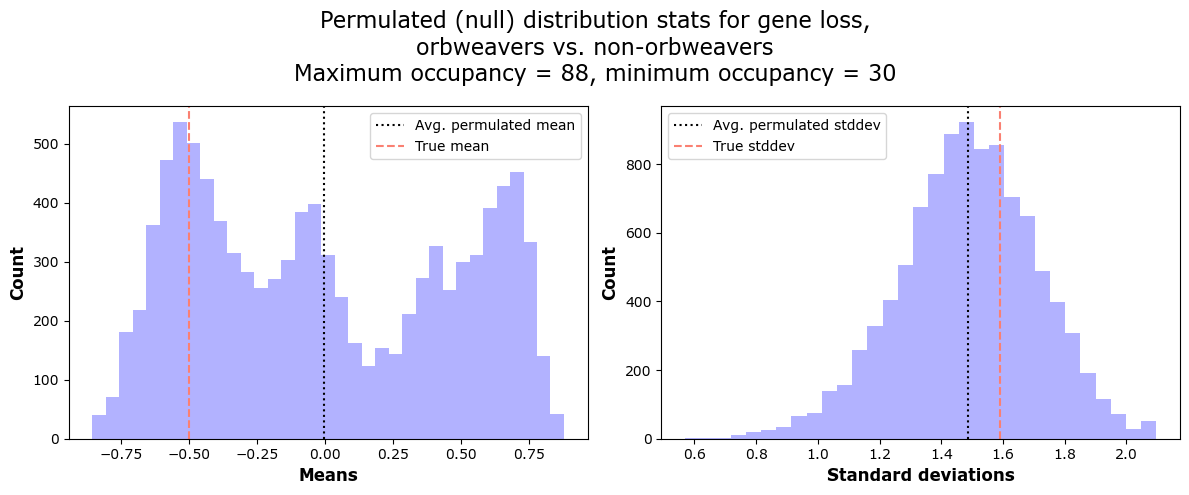

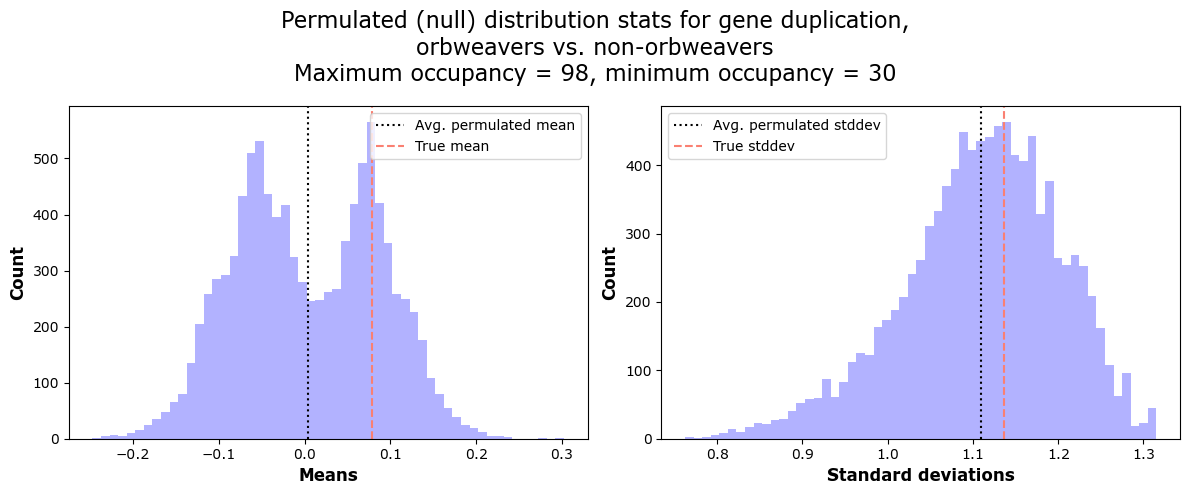

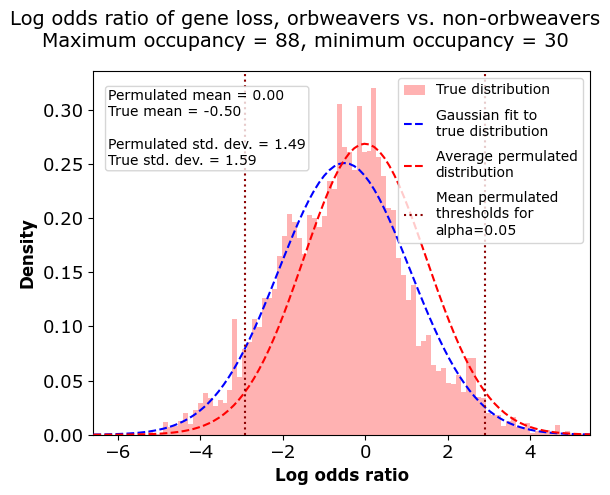

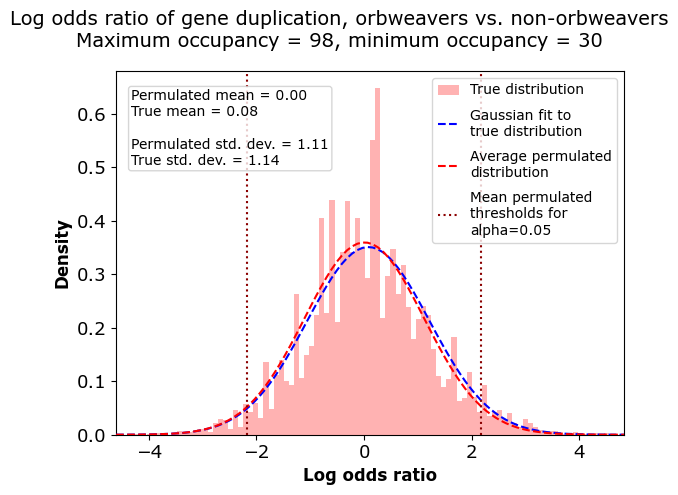

In [14]:
%autoreload 2
test = ort.odds_ratio_test(
    min_occ=30,
    max_occ=88,
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
    dir_suffix='all_orb'
)

In [10]:
%autoreload 2
results_all = ort.PermulationTestResults.load_from_pickle("results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb/results.pkl")
_, counts1, run1_df, total_count1 = results_all.filter_for_permulation_hits()
run1_df.head()

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant by avgd thresholds,Significant by permulation
HOG,,,,,,,,,
N5.HOG0001041,46,2.2880419958817027,-0.2817346202540693,0.0038,0.9962,0.5328,0.4672,,loss_fg
N5.HOG0001609,49,-2.8415866828425416,2.3914853308298487,0.9605,0.0395,0.0747,0.9253,,loss_bg
N5.HOG0001627,33,2.048042501668181,-4.020456662035705,0.0449,0.9551,0.9745,0.0253,dup_bg,"loss_fg, dup_bg"
N5.HOG0002031,46,-3.8236010086737187,1.8546381292872387,0.9996,0.0004,0.3311,0.6686,loss_bg,loss_bg
N5.HOG0002072,52,3.473732866474442,-0.7627257209774443,0.0108,0.9892,0.7989,0.2011,loss_fg,loss_fg


In [16]:
dup_res = results_all.results_df[results_all.results_df["Occupancy"]>=30][["Occupancy", "Log odds ratio of duplication", "P-value duplication more likely in fg", "P-value duplication more likely in bg"]]
dup_res.rename(columns={"Log odds ratio of duplication": "LOR",
                   "P-value duplication more likely in fg": "pval_fg",
                   "P-value duplication more likely in bg": "pval_bg"}, inplace=True)
dup_res

,Occupancy,LOR,pval_fg,pval_bg
HOG,,,,
N5.HOG0000042,30,0.813699,0.3212,0.6787
N5.HOG0000052,30,0.240563,0.2124,0.7876
N5.HOG0000147,34,0.691916,0.2807,0.7193
N5.HOG0000196,46,1.306972,0.1913,0.8087
N5.HOG0000276,30,0.230324,0.4794,0.5206
...,...,...,...,...
N5.HOG0073724,31,1.148432,0.4789,0.5209
N5.HOG0073740,30,0.194018,0.7552,0.2448
N5.HOG0073766,30,0.194018,0.7552,0.2448


In [17]:
loss_res = results_all.results_df[(results_all.results_df["Occupancy"]>=30) & (results_all.results_df["Occupancy"]<=88)][["Occupancy", "Log odds ratio of loss", "P-value loss more likely in fg", "P-value loss more likely in bg"]]
loss_res.rename(columns={"Log odds ratio of loss": "LOR",
                   "P-value loss more likely in fg": "pval_fg",
                   "P-value loss more likely in bg": "pval_bg"}, inplace=True)
loss_res

,Occupancy,LOR,pval_fg,pval_bg
HOG,,,,
N5.HOG0000042,30,-0.276367,0.5824,0.4176
N5.HOG0000052,30,0.097004,0.4532,0.5468
N5.HOG0000147,34,-1.828251,0.7268,0.2732
N5.HOG0000196,46,-0.376036,0.6819,0.3181
N5.HOG0000276,30,-3.135044,0.7295,0.2705
...,...,...,...,...
N5.HOG0073724,31,-0.968436,0.7919,0.2081
N5.HOG0073740,30,1.068957,0.1900,0.8100
N5.HOG0073766,30,0.466371,0.3631,0.6369


In [18]:
loss_res.to_csv(f"{repo_root}/results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb/perm_loss_pvalues.csv")
dup_res.to_csv(f"{repo_root}/results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb/perm_dup_pvalues.csv")

In [6]:
from odds_ratio_test_helpers import occupancy_filter
import pandas as pd
N5_genecount_df = pd.read_csv("/Users/calvin/orb-selection/data/N5.GeneCount.tsv", sep="\t")
occ_arr = N5_genecount_df["Occupancy"].values
pvals_loss_arr = results_all.results_df["P-value loss more likely in bg"].values
pvals_loss_fltrd = occupancy_filter(pvals_loss_arr, 30, 88, occ_arr)
len(pvals_loss_fltrd)

8291

(array([368., 342., 339., 334., 349., 382., 340., 318., 370., 400., 366.,
        350., 388., 346., 256., 228., 202., 234., 247., 215., 217., 206.,
        197., 173., 255., 174., 210., 177., 150., 158.]),
 array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
        0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
        0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
        0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 30 artists>)

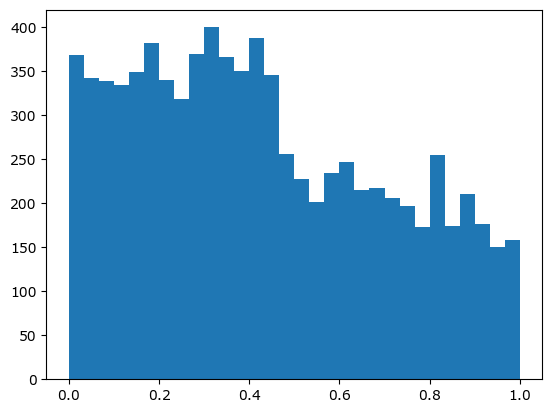

In [7]:
import matplotlib.pyplot as plt


plt.hist(pvals_loss_fltrd, bins=30)

(array([237., 378., 343., 389., 375., 383., 428., 475., 384., 403., 355.,
        422., 417., 429., 452., 327., 369., 420., 376., 418., 402., 412.,
        537., 425., 524., 499., 514., 445., 303., 255.]),
 array([0.        , 0.03332333, 0.06664667, 0.09997   , 0.13329333,
        0.16661667, 0.19994   , 0.23326333, 0.26658667, 0.29991   ,
        0.33323333, 0.36655667, 0.39988   , 0.43320333, 0.46652667,
        0.49985   , 0.53317333, 0.56649667, 0.59982   , 0.63314333,
        0.66646667, 0.69979   , 0.73311333, 0.76643667, 0.79976   ,
        0.83308333, 0.86640667, 0.89973   , 0.93305333, 0.96637667,
        0.9997    ]),
 <BarContainer object of 30 artists>)

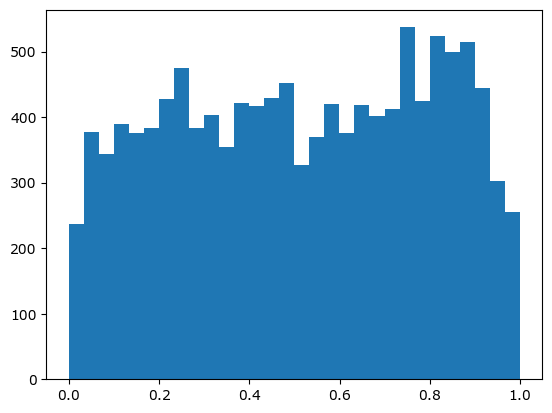

In [8]:
pvals_dup_arr = results_all.results_df["P-value duplication more likely in fg"].values
pvals_dup_fltrd = occupancy_filter(pvals_dup_arr, 30, None, occ_arr)
len(pvals_dup_fltrd)
plt.hist(pvals_dup_fltrd, bins=30)

In [8]:
run1_df[run1_df["Significant by avgd thresholds"] != ""]

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant by avgd thresholds,Significant by permulation
HOG,,,,,,,,,
N5.HOG0001627,33,2.048042501668181,-4.020456662035705,0.0449,0.9551,0.9745,0.0253,dup_bg,"loss_fg, dup_bg"
N5.HOG0002031,46,-3.8236010086737187,1.8546381292872387,0.9996,0.0004,0.3311,0.6686,loss_bg,loss_bg
N5.HOG0002072,52,3.473732866474442,-0.7627257209774443,0.0108,0.9892,0.7989,0.2011,loss_fg,loss_fg
N5.HOG0002078,42,-4.64814905627464,3.9760809321303596,0.9519,0.0481,0.0005,0.9995,"loss_bg, dup_fg","loss_bg, dup_fg"
N5.HOG0002348,65,-2.0357916420203486,2.270862603128372,0.8725,0.1275,0.0455,0.9545,dup_fg,dup_fg
...,...,...,...,...,...,...,...,...,...
N5.HOG0072918,33,-5.693836317970543,2.6592090830543094,1.0,0.0,0.0538,0.9462,loss_bg,loss_bg
N5.HOG0072996,32,-0.6826733991242648,2.239125359489152,0.8689,0.1311,0.0292,0.9708,dup_fg,dup_fg
N5.HOG0073071,35,-2.6510150184411816,2.2639256052709866,0.8765,0.1235,0.0175,0.9825,dup_fg,dup_fg


In [4]:
N5_count_df = results_all.true_odds.genecount_df.copy()
N5_count_df["occupancy"] = N5_count_df.select_dtypes(include="number").astype(
            "bool"
        ).sum(axis=1)
N5_count_df

,Acroaspis_sp_IDV6688,Acrosomoides_sp_IDV7426,Ainerigone_saitoi,Ambicodamus_IDV6680,Araneus_inustus,Arcuphantes_paiki,Arcuphantes_tamaensis,Arcuphantes_uenoi,Argiope_aetheroides,Argiope_bruennichi,...,Tetragnatha_quasimodo,Tetragnatha_stelarobusta,Tetragnatha_vermiformis,Tetragnatha_waikamoi,Tetragnatha_yesoensis,Theridion_varians,Uloborus_diversus,Ummeliata_osakaensis,Zelotes_iriomotensis,occupancy
HOG,,,,,,,,,,,,,,,,,,,,,
N5.HOG0000000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
N5.HOG0000001,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,0,0,0,0,23
N5.HOG0000002,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,9
N5.HOG0000003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
N5.HOG0000004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,3,0,0,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
N5.HOG0107981,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,1
N5.HOG0107982,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,1
N5.HOG0107983,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,1


In [5]:
dup_all_uni = N5_count_df[N5_count_df["occupancy"] >= results_all.min_occ].copy()

dup_all_uni.index

Index(['N5.HOG0000042', 'N5.HOG0000052', 'N5.HOG0000147', 'N5.HOG0000196',
       'N5.HOG0000276', 'N5.HOG0000428', 'N5.HOG0000526', 'N5.HOG0000608',
       'N5.HOG0000716', 'N5.HOG0001006',
       ...
       'N5.HOG0073590', 'N5.HOG0073630', 'N5.HOG0073702', 'N5.HOG0073709',
       'N5.HOG0073710', 'N5.HOG0073724', 'N5.HOG0073740', 'N5.HOG0073766',
       'N5.HOG0073773', 'N5.HOG0073818'],
      dtype='object', name='HOG', length=12096)

In [7]:
import numpy as np
np.savetxt(
    "/Users/calvin/orb-selection/data/N5_hogs_min_occ_30.txt",
    dup_all_uni.index.values,
    fmt="%s",
)